# Homework 3.2 — Differences-in-differences

## tl;dr

| Quiz question | Answer | Evidence |
|---|---|---|
| Q3: Largest estimated treatment effect | **B — Group 2** | **1.349859**, versus **0.685847** for Group 1 |
| Q4: Most statistically significant nonzero effect | **A — Group 1** | t = **10.969611**, versus **9.179774** for Group 2 |
| Q5: Closest listed effect for Group 2 | **B — 1.248** | Closest to the computed estimate of **1.349859** |

Both estimated effects are statistically different from zero using conventional
regression standard errors. Group 1 has the smaller p-value, despite its smaller
effect. **None of the Q5 options exactly matches the supplied CSV**; 1.248 is the
closest choice. Questions 1–2 are in `homework_3.1_event_studies.ipynb`.

## Context & Methods

Treat `homework_3.2.a.csv` as **Group 1** and `homework_3.2.b.csv` as
**Group 2**, following the column suffixes. Each dataset contains its own
treated and control observations. Within each file, `group=1` is treated,
`group=0` is control, `time=0` is before, and `time=1` is after.

Fit the following regression separately for the two datasets:

$$Y_i=\alpha+\beta\,Treated_i+\lambda\,Post_i
      +\tau(Treated_i\times Post_i)+\varepsilon_i.$$

The interaction coefficient $\tau$ is the differences-in-differences estimate:

$$\widehat\tau = (\overline Y_{T,after}-\overline Y_{T,before})
              -(\overline Y_{C,after}-\overline Y_{C,before}).$$

### Key Assumptions

- For causal interpretation, treatment and control would have had parallel
  changes without treatment, with no anticipation, spillovers, or differential
  concurrent shocks. With one before period, pre-treatment parallel trends
  cannot be tested from these files.
- Use every row and the group/time labels supplied in the CSV. Do not infer
  treatment assignment from row order. Each file has 1,000 observations.
- Use conventional OLS regression standard errors and two-sided Student-t tests.
  These treat errors as independent with constant variance within each dataset.
  The files contain no unit identifier for checking or modeling repeated-unit dependence.
- Q4 compares each dataset's evidence against its own zero-effect null; it does
  not test whether the two datasets' effects differ from one another.

If packages are missing, run `%pip install numpy pandas scipy matplotlib scikit-learn`.
Keep both CSVs in the project folder above `Homework Code`.

## Data

### 1. Set up the analysis

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from IPython.display import display, Markdown

pd.set_option('display.precision', 6)
plt.rcParams.update({
    'figure.figsize': (9, 4.8), 'figure.dpi': 110,
    'font.size': 11, 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E5E7EB', 'axes.axisbelow': True,
    'text.color': '#1F2937', 'axes.labelcolor': '#1F2937',
    'savefig.bbox': 'tight',
})
BLUE, GOLD, DARK = '#2563EB', '#B7791F', '#374151'

def locate_csv(filename):
    # Works from the project folder or any folder beneath it, including HW3.
    for folder in (Path.cwd(), *Path.cwd().parents):
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        f'Cannot find {filename}. Run from the project folder or a subfolder.'
    )

def show_table(frame, formats=None):
    display(frame.style.hide(axis='index').format(formats or {}, na_rep='—'))

### 2. Load and validate both datasets

In [2]:
FILES = {'Group 1': ('homework_3.2.a.csv', 1),
         'Group 2': ('homework_3.2.b.csv', 2)}
datasets = {}
source_rows = []
for label, (filename, number) in FILES.items():
    path = locate_csv(filename)
    source = pd.read_csv(path)
    required = [f'group{number}', f'time{number}', f'outcome{number}']
    if not set(required).issubset(source.columns):
        raise ValueError(f'{filename}: required columns {required}')
    frame = source[required].copy()
    frame.columns = ['treated', 'post', 'outcome']
    if not all(pd.api.types.is_numeric_dtype(frame[c]) for c in frame):
        raise TypeError(f'{filename}: analysis columns must be numeric.')
    if not np.isfinite(frame.to_numpy()).all():
        raise ValueError(f'{filename}: missing or infinite values.')
    for column in ['treated', 'post']:
        if set(frame[column].unique()) != {0, 1}:
            raise ValueError(f'{filename}: {column} must contain both 0 and 1.')
    if len(frame.groupby(['treated', 'post'])) != 4:
        raise ValueError(f'{filename}: all four treatment/period cells are required.')
    datasets[label] = frame
    source_rows.append({'Dataset': label, 'File': filename, 'Rows': len(frame),
                        'Missing values': int(frame.isna().sum().sum()),
                        'Duplicate rows': int(frame.duplicated().sum())})
    print(f'{filename} SHA-256: {hashlib.sha256(path.read_bytes()).hexdigest()}')
show_table(pd.DataFrame(source_rows))

homework_3.2.a.csv SHA-256: 64b3b3524b79cd6b1a7f0fc3616bacb4be5f8e84ccfe0e9b4df24cade5a03a0d
homework_3.2.b.csv SHA-256: a64341e2eb74df802a9f4e6d052e6614967bf17cbe0e4e4f7b7b9bf8d623a342


Dataset,File,Rows,Missing values,Duplicate rows
Group 1,homework_3.2.a.csv,1000,0,0
Group 2,homework_3.2.b.csv,1000,0,0


### 3. Inspect the four cells in each dataset

In [3]:
cell_tables = []
cell_means = {}
for label, frame in datasets.items():
    summary = frame.groupby(['treated', 'post']).agg(
        Observations=('outcome', 'size'), Mean=('outcome', 'mean'),
        SD=('outcome', 'std'),
    ).reset_index()
    summary.insert(0, 'Dataset', label)
    cell_tables.append(summary)
    cell_means[label] = frame.groupby(['treated', 'post'])['outcome'].mean().unstack('post')
cell_summary = pd.concat(cell_tables, ignore_index=True)
readable_cells = cell_summary.rename(columns={'treated': 'Treatment', 'post': 'Period'})
readable_cells['Treatment'] = readable_cells['Treatment'].map({0: 'Control', 1: 'Treated'})
readable_cells['Period'] = readable_cells['Period'].map({0: 'Before', 1: 'After'})
show_table(readable_cells, {'Mean': '{:.6f}', 'SD': '{:.6f}'})

Dataset,Treatment,Period,Observations,Mean,SD
Group 1,Control,Before,251,-0.025849,0.506878
Group 1,Control,After,250,1.401364,0.491931
Group 1,Treated,Before,249,1.960429,0.467574
Group 1,Treated,After,250,4.073489,0.509466
Group 2,Control,Before,251,0.102107,1.196622
Group 2,Control,After,250,1.367621,1.116643
Group 2,Treated,Before,249,1.949826,1.137960
Group 2,Treated,After,250,4.565198,1.196398


## Results

### 4. Fit the differences-in-differences regressions

This helper explicitly computes conventional OLS uncertainty:
$SE(\widehat\tau)$ is the square root of the interaction's diagonal element
in $\widehat\sigma^2(X^TX)^{-1}$, with
$\widehat\sigma^2=\sum_i\widehat\varepsilon_i^2/(n-4)$.

In [4]:
def fit_ols(outcome, design):
    """OLS with an explicit intercept column and conventional regression SEs."""
    X = design.to_numpy(dtype=float)
    y = np.asarray(outcome, dtype=float)
    n, k = X.shape
    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError('The regression contains missing or infinite values.')
    if np.linalg.matrix_rank(X) != k or n <= k:
        raise ValueError('The design must have full rank and positive residual df.')

    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    fitted = X @ beta
    residuals = y - fitted
    residual_df = n - k
    residual_variance = (residuals @ residuals) / residual_df
    covariance = residual_variance * np.linalg.inv(X.T @ X)
    standard_errors = np.sqrt(np.diag(covariance))
    t_values = beta / standard_errors
    critical_t = stats.t.ppf(0.975, residual_df)
    coefficients = pd.DataFrame({
        'Estimate': beta,
        'SE': standard_errors,
        't': t_values,
        'p-value': 2 * stats.t.sf(np.abs(t_values), residual_df),
        '95% CI lower': beta - critical_t * standard_errors,
        '95% CI upper': beta + critical_t * standard_errors,
    }, index=design.columns)
    return {
        'coefficients': coefficients, 'fitted': fitted,
        'residual_variance': residual_variance, 'residual_df': residual_df,
    }

COEF_FORMAT = {column: '{:.6f}' for column in
               ['Estimate', 'SE', 't', '95% CI lower', '95% CI upper']}
COEF_FORMAT['p-value'] = '{:.3e}'

In [5]:
models = {}
designs = {}
all_coefficients = []
for label, frame in datasets.items():
    design = pd.DataFrame({
        'Intercept': 1.0, 'Treated': frame['treated'], 'Post': frame['post'],
        'Treated x Post': frame['treated'] * frame['post'],
    })
    designs[label] = design
    models[label] = fit_ols(frame['outcome'], design)
    table = models[label]['coefficients'].rename_axis('Term').reset_index()
    table.insert(0, 'Dataset', label)
    all_coefficients.append(table)
show_table(pd.concat(all_coefficients, ignore_index=True), COEF_FORMAT)

Dataset,Term,Estimate,SE,t,p-value,95% CI lower,95% CI upper
Group 1,Intercept,-0.025849,0.031199,-0.828535,4.076e-01,-0.087072,0.035374
Group 1,Treated,1.986278,0.044210,44.928019,9.367e-242,1.899522,2.073034
Group 1,Post,1.427213,0.044166,32.314876,2.874e-157,1.340544,1.513882
Group 1,Treated x Post,0.685847,0.062522,10.969611,1.640e-26,0.563156,0.808538
Group 2,Intercept,0.102107,0.073377,1.391551,1.644e-01,-0.041883,0.246098
Group 2,Treated,1.847719,0.103978,17.770217,1.409e-61,1.643677,2.051761
Group 2,Post,1.265513,0.103874,12.183163,6.298e-32,1.061676,1.469350
Group 2,Treated x Post,1.349859,0.147047,9.179774,2.432e-19,1.061301,1.638417


### 5. Q3 and Q4 — Compare magnitude and statistical significance

In [6]:
effect_results = pd.DataFrame([
    {'Dataset': label, **model['coefficients'].loc['Treated x Post'].to_dict()}
    for label, model in models.items()
])
show_table(effect_results, COEF_FORMAT)
largest_effect = effect_results.loc[effect_results['Estimate'].idxmax(), 'Dataset']
most_significant = effect_results.loc[effect_results['p-value'].idxmin(), 'Dataset']
assert most_significant == effect_results.loc[effect_results['t'].abs().idxmax(), 'Dataset']
display(Markdown(f'**Q3: B — {largest_effect}. Q4: A — {most_significant}.** '
    'Statistical significance depends on the estimate relative to its standard error, '
    'not the estimate alone. Both effects are significantly different from zero.'))

Dataset,Estimate,SE,t,p-value,95% CI lower,95% CI upper
Group 1,0.685847,0.062522,10.969611,1.640e-26,0.563156,0.808538
Group 2,1.349859,0.147047,9.179774,2.432e-19,1.061301,1.638417


**Q3: B — Group 2. Q4: A — Group 1.** Statistical significance depends on the estimate relative to its standard error, not the estimate alone. Both effects are significantly different from zero.

Group 2’s effect is about twice Group 1’s, but its standard error is about 2.35 times as large. Group 1 therefore has the larger t statistic (10.97 versus 9.18) and smaller p-value (1.640 × 10⁻²⁶ versus 2.432 × 10⁻¹⁹).

### 6. Check the regression against the difference of four cell means

In [7]:
manual_rows = []
for label, means in cell_means.items():
    treated_change = means.loc[1, 1] - means.loc[1, 0]
    control_change = means.loc[0, 1] - means.loc[0, 0]
    manual_effect = treated_change - control_change
    regression_effect = models[label]['coefficients'].loc['Treated x Post', 'Estimate']
    np.testing.assert_allclose(manual_effect, regression_effect, atol=1e-12)
    manual_rows.append({'Dataset': label, 'Treated change': treated_change,
                       'Control change': control_change, 'DiD effect': manual_effect})

    # Independently recover the pooled four-cell regression standard error.
    frame = datasets[label]
    cells = frame.groupby(['treated', 'post'])['outcome'].agg(['count', 'var'])
    pooled_variance = ((cells['count'] - 1) * cells['var']).sum() / (len(frame) - 4)
    manual_se = np.sqrt(pooled_variance * (1 / cells['count']).sum())
    np.testing.assert_allclose(manual_se,
        models[label]['coefficients'].loc['Treated x Post', 'SE'], atol=1e-12)

    check = LinearRegression(fit_intercept=False).fit(designs[label], frame['outcome'])
    np.testing.assert_allclose(check.coef_, models[label]['coefficients']['Estimate'], atol=1e-12)

show_table(pd.DataFrame(manual_rows), {
    column: '{:.6f}' for column in ['Treated change', 'Control change', 'DiD effect']
})
print('Checks passed: four-cell DiD, pooled regression SEs, and independent regression coefficients.')

Dataset,Treated change,Control change,DiD effect
Group 1,2.113060,1.427213,0.685847
Group 2,2.615372,1.265513,1.349859


Checks passed: four-cell DiD, pooled regression SEs, and independent regression coefficients.


### 7. Visualize the before-and-after changes

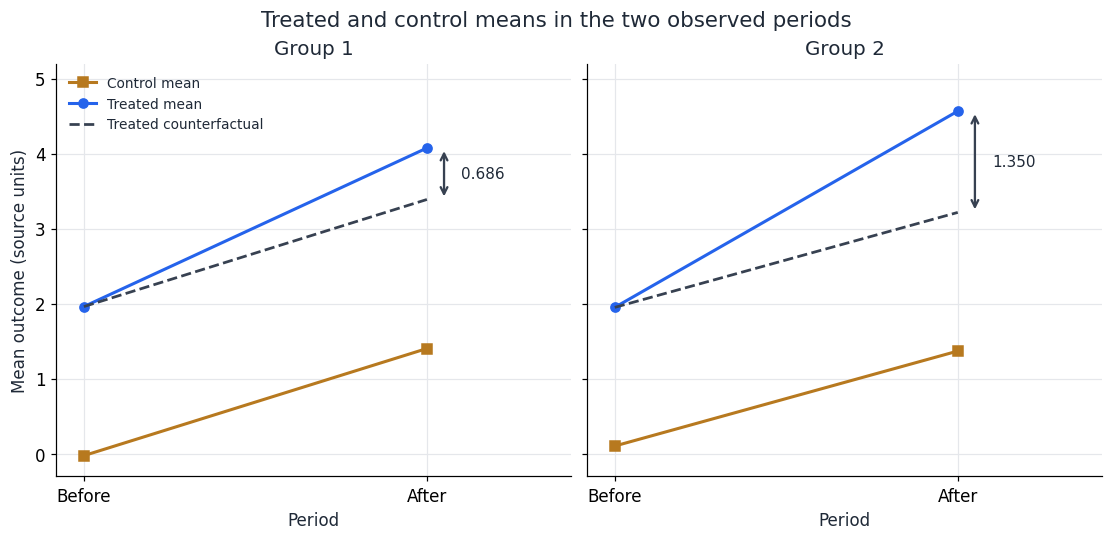

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), sharey=True, constrained_layout=True)
for ax, (label, means) in zip(axes, cell_means.items()):
    control = means.loc[0, [0, 1]].to_numpy()
    treated = means.loc[1, [0, 1]].to_numpy()
    counterfactual = np.array([treated[0], treated[0] + control[1] - control[0]])
    effect = treated[1] - counterfactual[1]
    ax.plot([0, 1], control, 's-', color=GOLD, linewidth=2, label='Control mean')
    ax.plot([0, 1], treated, 'o-', color=BLUE, linewidth=2, label='Treated mean')
    ax.plot([0, 1], counterfactual, '--', color=DARK, linewidth=1.8,
            label='Treated counterfactual')
    ax.annotate('', xy=(1.05, treated[1]), xytext=(1.05, counterfactual[1]),
                arrowprops={'arrowstyle': '<->', 'color': DARK, 'lw': 1.5})
    ax.text(1.10, (treated[1] + counterfactual[1]) / 2, f'{effect:.3f}',
            va='center', fontsize=10)
    ax.set_title(label)
    ax.set_xticks([0, 1], ['Before', 'After'])
    ax.set_xlabel('Period')
    ax.set_xlim(-0.08, 1.42)
    ax.set_ylim(-0.3, 5.2)
axes[0].set_ylabel('Mean outcome (source units)')
axes[0].legend(frameon=False, loc='upper left', fontsize=9)
fig.suptitle('Treated and control means in the two observed periods', fontsize=14)
plt.show()

The dashed counterfactual adds the control group’s observed change to the treated group’s before mean. Its after-period gap from the treated mean is the DiD estimate. The two observed periods do not provide a pre-treatment trend test.

### 8. Plot the estimated effects and 95% confidence intervals

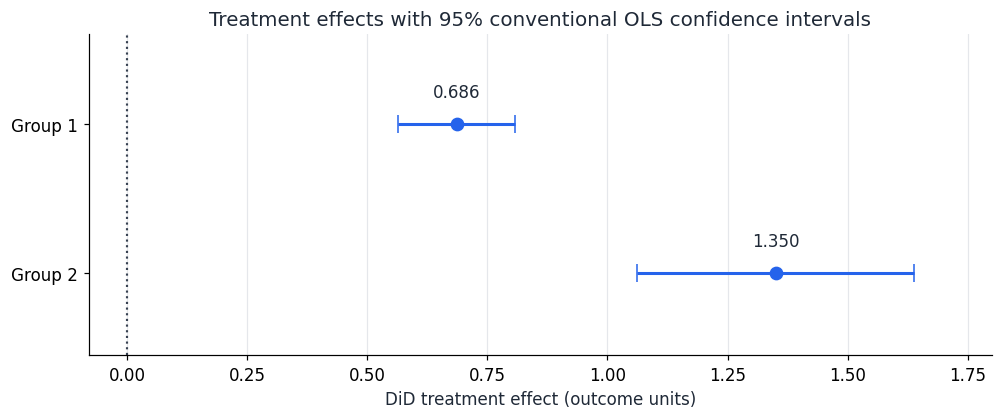

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.7), constrained_layout=True)
for position, row in effect_results.iterrows():
    estimate = row['Estimate']
    ax.errorbar(estimate, position,
                xerr=[[estimate - row['95% CI lower']], [row['95% CI upper'] - estimate]],
                fmt='o', color=BLUE, markersize=8, capsize=6, linewidth=2)
    ax.text(estimate, position - 0.18, f'{estimate:.3f}', ha='center', fontsize=11)
ax.axvline(0, color=DARK, linestyle=':', linewidth=1.4)
ax.set_yticks([0, 1], effect_results['Dataset'])
ax.set_ylim(1.55, -0.6)
ax.set_xlim(-0.08, 1.8)
ax.set_xlabel('DiD treatment effect (outcome units)')
ax.set_title('Treatment effects with 95% conventional OLS confidence intervals')
ax.grid(axis='y', visible=False)
plt.show()

Both intervals exclude zero. The point estimates answer Q3; the t statistics and p-values in the table answer Q4.

### 9. Q5 — Find the closest multiple-choice value

In [10]:
group2_effect = models['Group 2']['coefficients'].loc['Treated x Post', 'Estimate']
options = pd.DataFrame({'Option': ['A', 'B', 'C'], 'Listed value': [0.5831, 1.248, 4.209]})
options['Absolute distance'] = (options['Listed value'] - group2_effect).abs()
show_table(options, {'Listed value': '{:.4f}', 'Absolute distance': '{:.6f}'})
closest = options.loc[options['Absolute distance'].idxmin()]
display(Markdown(
    f'**Q5: Option {closest["Option"]} — {closest["Listed value"]:.3f}.** '
    f'The actual estimate from the supplied CSV is **{group2_effect:.6f}**. '
    f'The nearest choice differs by {closest["Absolute distance"]:.6f}; '
    'the calculation is independently confirmed by the four cell means above.'
))

Option,Listed value,Absolute distance
A,0.5831,0.766759
B,1.2480,0.101859
C,4.2090,2.859141


**Q5: Option B — 1.248.** The actual estimate from the supplied CSV is **1.349859**. The nearest choice differs by 0.101859; the calculation is independently confirmed by the four cell means above.

## Takeaways

Select **Q3: B — Group 2**, **Q4: A — Group 1**, and **Q5: B — 1.248**. Effect size and statistical significance answer different questions. Keep **1.349859** as the computed Group 2 estimate; **1.248** is only the closest quiz choice.

### Reproducibility

In [11]:
print('Python:', platform.python_version())
for package in ['numpy', 'pandas', 'scipy', 'matplotlib', 'scikit-learn']:
    print(f'{package}: {importlib.metadata.version(package)}')

Python: 3.13.5
numpy: 2.4.1
pandas: 3.0.0
scipy: 1.17.0
matplotlib: 3.10.8
scikit-learn: 1.8.0
